<font size=3;>
<p style="text-align: right;"> Lab Solution --- <b>NOT FOR DISTRIBUTION!</b> </p>
</font>

# Lab F: One-Sample t Hypothesis Test

## Setup

In [1]:
# Import some useful functions
from numpy import *
from numpy.random import *
from datascience import *
from statsmodels.formula.api import *

# Define some useful functions
def correlation(array_1, array_2):
    return corrcoef(array_1, array_2).item(1)

# Customize look of graphics
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 60
%matplotlib inline

# Force display of all values 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Hide some unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")
import numpy
numpy.int = numpy.int_

## Customer Satisfaction Alarm - known population (unrealistic business situation)

### Business Decision

A customer service organization in a large multi-national conglomerate serves about 100,000 customers.  Each month, an independent vendor interviews 10 customers chosen at random for their levels of customer satisfaction.  The scores range from 0 for highly dissatisfied to 100 for highly satisfied.  The vendor then reports the average score for this sample of customers to the Vice President of Customer Service.  Historically, the average score for a sample of 10 customers has usually been about 75, which the Vice President considers acceptable.

For this analysis, suppose (somewhat unrealistically) that you know the satisfaction levels of all customers. 

### Data

Retrieve the satisfaction levels of all customers from the file 'Population CSat1.csv'.
Show the population size, the population mean score, and a histogram of the population scores (100 bins, range 0 to 100).

score
78.0212
75.1528
83.7926
71.5286
81.0647
80.514
83.3964
77.2003
71.6591
68.6084


99911

74.976096730661951

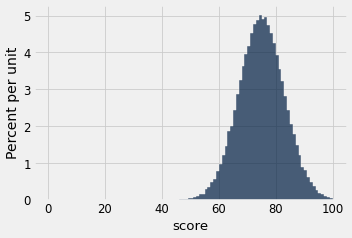

In [2]:
data = Table.read_table('Population_CSat1.csv')
data

pop_mean = mean(data.column('score'))

data.num_rows
pop_mean
data.hist(bins=100, range=make_array(0,100))

### Analysis

#### Sample 

Set sample size to 10.

In [3]:
sample_size = 10
sample_size

10

Set the randomization seed to 4, get a sample, show the sample scores,
and show a histogram of the sample scores (100 bins, range 0 to 100).

score
83.372
56.4713
74.2397
69.0226
85.6648
71.241
71.8123
77.4627
68.5839
74.5625


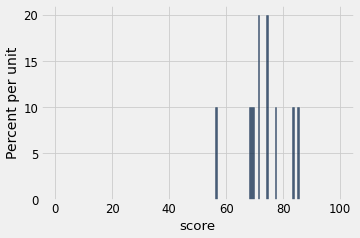

In [4]:
seed(4)

sample = data.sample(sample_size)

sample
sample.hist(bins=100, range=make_array(0,100))

Show the sample mean.

In [5]:
sample_mean = mean(sample.column('score'))
sample_mean

73.243283788053958

Show the sample standard deviation.

In [6]:
sample_std = std(sample.column('score'), ddof=1)
sample_std

8.194196466013258

Calculate and show the sample t @ population mean 75.00.

sample t = (sample mean - population mean) / (sample standard deviation / sqrt(sample size))

In [7]:
sample_t = (sample_mean - pop_mean) / (sample_std / sqrt(sample_size))
sample_t

-0.66872153729625039

#### Distribution of Sample t's

Get a new sample of 10 customers.
Show the sample scores.
Calculate and show the sample t.  Visualize as a histogram of the **sample scores** (100 bins, range 0 to 100).

Try this several times and notice that the shapes of the histograms are dissimilar.

score
71.4291
66.9816
89.9257
93.2993
84.6171
90.4273
71.1844
75.2673
67.5459
61.5481


0.62387984171910893

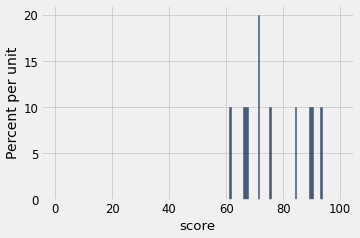

In [8]:
sample_i = data.sample(sample_size)
sample_mean_i = mean(sample_i.column('score'))
sample_std_i = std(sample_i.column('score'), ddof=1)
sample_t_i = (sample_mean_i - pop_mean) / (sample_std_i / sqrt(sample_size))

sample_i
sample_t_i
sample_i.hist(bins=100, range=make_array(0,100))

Get 5 new samples of 10 customers each.  Calculate and show the sample t's.  Visualize as a histogram of the **sample t's** (50 bins, range -4 to 4).

Try this several times and notice that the shapes of the histograms are dissimilar.

t
-0.027794
0.427135
1.46362
-0.791103
3.37278


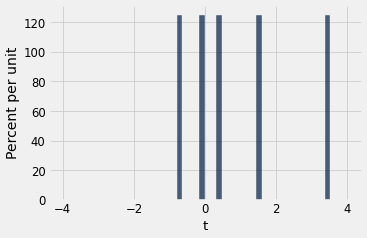

In [9]:
dist_array = make_array()

for i in arange(5):
    sample_i = data.sample(sample_size)
    sample_mean_i = mean(sample_i.column('score'))
    sample_std_i = std(sample_i.column('score'), ddof=1)
    sample_t_i = (sample_mean_i - pop_mean) / (sample_std_i / sqrt(sample_size)) # caution: potential divide by zero
    dist_array = append(dist_array, sample_t_i)
    
dist = Table().with_column('t', dist_array)

dist
dist.hist(bins=50, range=make_array(-4,4))

Get 100,000 new samples of 10 customers each.  Calculate and show the first few sample t's.  Visualize as a histogram of the sample t's (50 bins, range -4 to 4).

Try this several times and notice that the shapes of the histograms are similar.

t
1.49569
1.20906
0.994288
-0.800688
-0.715097
-0.403121
-0.177759
1.23218
0.0790889
-0.636078


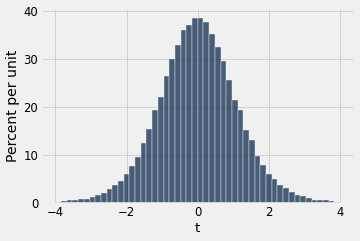

In [10]:
dist_array = make_array()

for i in arange(100000):
    sample_i = data.sample(sample_size)
    sample_mean_i = mean(sample_i.column('score'))
    sample_std_i = std(sample_i.column('score'), ddof=1)
    sample_t_i = (sample_mean_i - pop_mean) / (sample_std_i / sqrt(sample_size)) # caution: potential divide by zero
    dist_array = append(dist_array, sample_t_i)
    
dist = Table().with_column('t', dist_array)

dist
dist.hist(bins=50, range=make_array(-4,4))

Calculate and show the probability of getting a sample t $\le$ -0.6687
(when population mean is 75.00 and sample size is 10).
Visualize as a histogram of standard t's with the area corresponding to the probability highlighted (50 bins, range -4 to 4).

-0.66872153729625039

0.2614

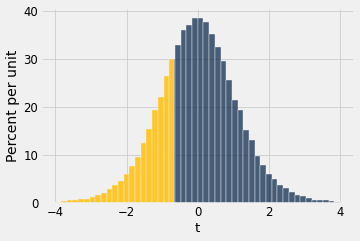

In [11]:
prob = dist.where('t', are.below_or_equal_to(sample_t)).num_rows / dist.num_rows

sample_t
prob
dist.hist(bins=50, range=make_array(-4,4), left_end=-4, right_end=sample_t)

There was a 26.14\% probability of getting a sample like the one we did.  That's not a surprising result.

## Customer Satisfaction Alarm - unknown population (realistic business situation)

### Business Decision

As in Part 2, our customer service organization has hired a vendor to interview some of its customers monthly.  For this analysis, suppose (somewhat realistically) that you do NOT know the satisfaction levels of all customers.

This month, the average of 10 customer satisfaction scores is far below 75.  The Vice President of Customer Service must decide whether to initiate action to address low customer satisfaction.

### Data

You get a sample with scores that look like this:  
63.1142, 86.2235, 75.3150, 62.5061, 73.3992, 67.3861, 53.3442, 67.4657, 76.6753, 67.5086

In [12]:
sample = Table().with_column('score', make_array(63.1142, 86.2235, 75.3150, 62.5061, 73.3992, 67.3861, 53.3442, 67.4657, 76.6753, 67.5086))

sample

score
63.1142
86.2235
75.315
62.5061
73.3992
67.3861
53.3442
67.4657
76.6753
67.5086


### Analysis

#### Hypothesis

Hypothesize that the population mean $\ge$ 75.00.  This would be business as usual and not require action.

In [13]:
pop_mean_hypo = 75.00
pop_mean_hypo

75.0

#### Sample

Show the sample size, sample mean, sample standard deviation, sample t, and a histogram of the sample scores (100 bins, range 0 to 100).

10

69.293789999999987

9.086184375125665

-1.9859403752171698

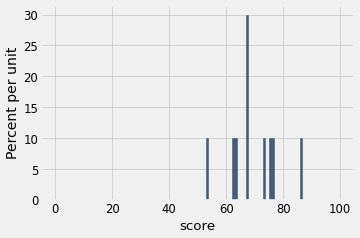

In [14]:
sample_size = sample.num_rows
sample_mean = mean(sample.column('score'))
sample_std = std(sample.column('score'), ddof=1)
sample_t = (sample_mean - pop_mean_hypo) / (sample_std / sqrt(sample_size))

sample_size
sample_mean
sample_std
sample_t
sample.hist(bins=100, range=make_array(0,100))

Because the sample mean is less than the hypothesized population mean, we suspect that the real population mean might be less than the hypothesized population mean.  Note that what we suspect is the opposite of the hypothesis. 

#### Standard t Distribution

Get 1,000,000 values from the standard t distribution for sample size 10.  To do this, use standard_t(10-1, 1000000).  Visualize as a histogram of all the standard t's. (50 bins, range -4 to 4).

Treat the standard t distribution as the population t distribution.

t
-1.3462
3.0717
0.188082
-0.267514
-0.0278289
0.10059
-0.335567
-0.614093
-1.7624
0.827296


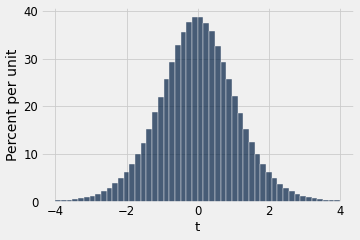

In [15]:
df = sample_size-1
dist_array = standard_t(df, 1000000)
dist = Table().with_column('t', dist_array)

dist
dist.hist(bins=50, range=make_array(-4,4))

#### p-Value

Show the sample t.  Calculate and show the probability that the sample t $\le$ -1.9859 when pop mean $\ge$ 75.00 (this is the p-value).  Visualize as a histogram of standard t's with the area corresponding to the probability highlighted (50 bins, range -4 to 4).

-1.9859403752171698

0.039506

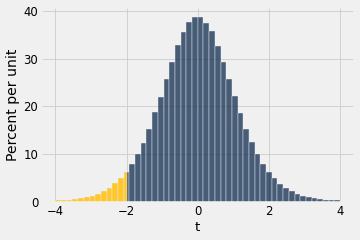

In [16]:
p_value = dist.where('t', are.below_or_equal_to(sample_t)).num_rows / dist.num_rows

sample_t
p_value
dist.hist(bins=50, range=make_array(-4,4), left_end=-4, right_end=sample_t)

#### Conclusion at Significance Level 0.05

Set and show the significance level 0.05.  Calculate and show the critical value at significance level 0.05 based on the standard t distribution for sample size 10.  Note that the suspected population mean is BELOW the hypothesized population mean.  Visualize as a histogram of standard t's with the area corresponding to the significance level highlighted (50 bins, range -4 to 4).

0.05

-1.8366789642342913

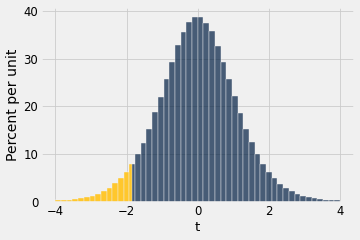

In [19]:
sig_level = 0.05
cv = percentile(sig_level*100, dist.column('t'))

sig_level
cv
dist.hist(bins=50, range=make_array(-4,4), left_end=-4, right_end=cv)

Calculate and show that you should conclude the hypothesis is not correct (i.e., conclude population mean < 75.00), at significance level 0.05.

In [20]:
p_value > sig_level
sample_t > cv

False

False

If average customer satisfaction of all customers were really 75 or higher, then there would be only a 3.39% probability of getting a sample like the one we did.  Although that's possible, it's very unlikely, so the Vice President of Customer Service decides to initiate action to address low customer satisfaction.

<p style="text-align:left; font-size:10px;">
Copyright (c) Huntsinger Associates, LLC
<span style="float:right;">
Document revised October 5, 2024
</span>
</p>